# Immutable snapshot and leakage audit

Validate canonical map identity, temporal cutoffs, source coverage, and sparsity before modeling.

This notebook is generated from immutable, hash-manifested artifacts. Any
counterfactual agent or composition result is predictive/associational,
not a causal estimate.

In [1]:
from pathlib import Path

SNAPSHOT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2")
DEVELOPMENT = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full")
CONFIRMATION = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation")
SCORING_V3 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3")
SCORING_V2 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v2")
SCORING_V1 = Path(r"C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots")
SCORING = SCORING_V3 if SCORING_V3.exists() else (SCORING_V2 if SCORING_V2.exists() else SCORING_V1)

print("snapshot:", SNAPSHOT)
print("development:", DEVELOPMENT if DEVELOPMENT.exists() else "not supplied")
print("confirmation:", CONFIRMATION if CONFIRMATION.exists() else "not available")
print("scoring:", SCORING if SCORING.exists() else "not available")

snapshot: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\data\snapshots\vct_2023_2026_cutoff_2026-06-21_v2
development: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full
confirmation: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__2026-confirmation
scoring: C:\Users\benja\projects\valorant-elo-dashboard\research\ratings\artifacts\ratings-development-v1-full__rating-snapshots-v3


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

manifest = json.loads((SNAPSHOT / "manifest.json").read_text(encoding="utf-8"))
tables = {
    name: pd.read_parquet(SNAPSHOT / f"{name}.parquet")
    for name in ("maps", "player_maps", "rosters", "vetoes")
}
summary = pd.DataFrame(
    {
        "table": name,
        "rows": len(frame),
        "columns": len(frame.columns),
    }
    for name, frame in tables.items()
)
display(summary)
print("data sha256:", manifest["data_sha256"])
print("cutoff:", manifest["cutoff"])

,table,rows,columns
0,maps,3818,31
1,player_maps,38180,43
2,rosters,1062,12
3,vetoes,10466,7


data sha256: 97e36e8f5eb4c2cfa448adf466a47983094f08593f1b9f9b3a2f4efbc98caef9
cutoff: 2026-06-21T23:59:59.999999+00:00


In [3]:
maps = tables["maps"].copy()
player_maps = tables["player_maps"].copy()
cutoff = pd.Timestamp(manifest["cutoff"])
prediction_times = pd.to_datetime(maps["prediction_cutoff"], utc=True)

checks = pd.Series(
    {
        "one row per map_id": not maps["map_id"].duplicated().any(),
        "all prediction cutoffs within snapshot": bool((prediction_times <= cutoff).all()),
        "ten player rows per map": bool(player_maps.groupby("map_id").size().eq(10).all()),
        "positive score-derived total rounds": bool((maps["total_rounds"] > 0).all()),
        "player rows reference canonical maps": bool(player_maps["map_id"].isin(maps["map_id"]).all()),
    },
    name="passed",
)
display(checks.to_frame())
assert checks.all(), checks[~checks].index.tolist()

missing = player_maps[[column for column in ("adr", "kast", "acs") if column in player_maps]].isna().mean()
display(missing.rename("missing_fraction").to_frame())

,passed
one row per map_id,True
all prediction cutoffs within snapshot,True
ten player rows per map,True
positive score-derived total rounds,True
player rows reference canonical maps,True


,missing_fraction
adr,0.068622
kast,0.105815
acs,0.003143


,maps
median maps/player,45.0
median player-map,5.0
median player-agent,5.0
median player-map-agent,2.0
median exact context,1.0


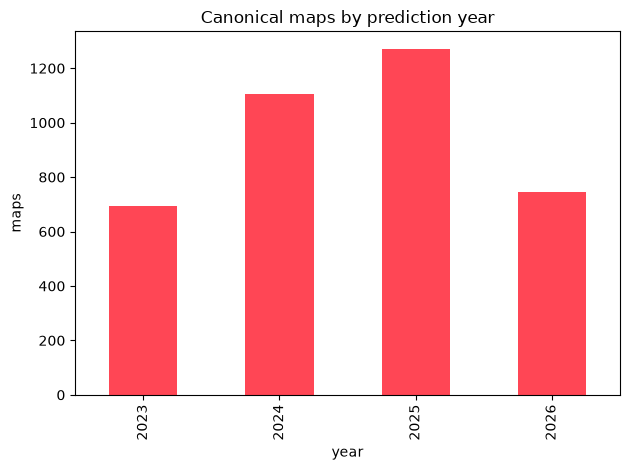

In [4]:
composition = (
    player_maps.groupby(["map_id", "team_id"])["agent"]
    .agg(lambda values: "|".join(sorted(map(str, values))))
    .rename("composition")
    .reset_index()
)
support = player_maps.merge(composition, on=["map_id", "team_id"], validate="many_to_one")
sparsity = pd.Series(
    {
        "median maps/player": support.groupby("player_id").size().median(),
        "median player-map": support.groupby(["player_id", "map_name"]).size().median(),
        "median player-agent": support.groupby(["player_id", "agent"]).size().median(),
        "median player-map-agent": support.groupby(["player_id", "map_name", "agent"]).size().median(),
        "median exact context": support.groupby(["player_id", "map_name", "agent", "composition"]).size().median(),
    },
    name="maps",
)
display(sparsity.to_frame())

yearly = prediction_times.dt.year.value_counts().sort_index()
ax = yearly.plot.bar(title="Canonical maps by prediction year", color="#ff4655")
ax.set(xlabel="year", ylabel="maps")
plt.tight_layout()
plt.show()